In [1]:
import pandas as pd
import numpy as np

### GPTOSS-ENGLISH DATASET

##### BIAS-REFUSAL 

GenderVsRefusal: [0.2968444228172302, 0.17962175607681274, 0.1019969955086708, -0.021877171471714973, -0.17878559231758118, -0.3158462941646576, -0.42811352014541626, -0.2656780779361725, -0.3605790436267853, -0.32132431864738464, -0.346055269241333, -0.26375722885131836, -0.30615174770355225, -0.1880461871623993]
RaceVsRefusal: [0.34902042150497437, 0.19163508713245392, 0.06488973647356033, -0.0001305053010582924, -0.11337216198444366, -0.25254830718040466, -0.310097336769104, -0.20421497523784637, -0.28238481283187866, -0.16898097097873688, -0.23937468230724335, -0.13282006978988647, -0.1941080391407013, -0.28753310441970825]
ReligionVsRefusal: [0.28198716044425964, 0.11705262959003448, 0.048433657735586166, -0.029225800186395645, -0.17975586652755737, -0.3457286059856415, -0.45747315883636475, -0.35219788551330566, -0.4224606156349182, -0.23726949095726013, -0.23671388626098633, -0.08494725823402405, -0.14798025786876678, -0.22606560587882996]

Mean cosine similarities:
Race vs Refu

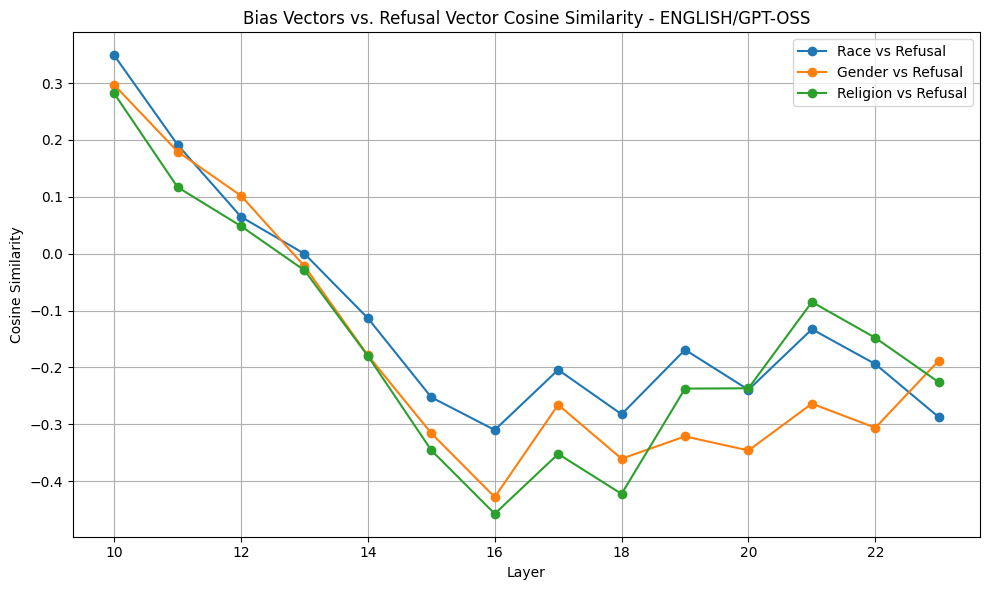

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# GPT-OSS usually has layers 0–23, so layer 10 to 23
layers = list(range(10, 24))

bias_types = [
    "race_rlhf_wrapper",
    "gender_rlhf_wrapper",
    "religion_rlhf_wrapper"
]

# Base directory for GPT-OSS vectors
base_dir = "/home/chakrabort/Documents/Gptoss"

cosine_similarities = {bias: [] for bias in bias_types}

for layer in layers:
    refusal_path = f"{base_dir}/refusal_rlhf_wrapper/vec_layer_{layer}.pt"
    refusal_vec = torch.load(refusal_path, map_location="cpu").float()

    for bias in bias_types:
        bias_path = f"{base_dir}/{bias}/vec_layer_{layer}.pt"
        bias_vec = torch.load(bias_path, map_location="cpu").float()

        if refusal_vec.dim() != 1 or bias_vec.dim() != 1:
            raise ValueError(
                f"Expected 1D vectors at layer {layer}; "
                f"got refusal {tuple(refusal_vec.shape)} and {bias} {tuple(bias_vec.shape)}"
            )

        if refusal_vec.numel() != bias_vec.numel():
            raise ValueError(
                f"Hidden-size mismatch at layer {layer} for {bias}: "
                f"refusal={refusal_vec.numel()}, bias={bias_vec.numel()}"
            )

        sim = F.cosine_similarity(
            refusal_vec.unsqueeze(0),
            bias_vec.unsqueeze(0),
            dim=1
        )

        cosine_similarities[bias].append(sim.item())

# Print cosine similarities per layer
print("GenderVsRefusal:", cosine_similarities["gender_rlhf_wrapper"])
print("RaceVsRefusal:", cosine_similarities["race_rlhf_wrapper"])
print("ReligionVsRefusal:", cosine_similarities["religion_rlhf_wrapper"])

print("\nMean cosine similarities:")
for bias in bias_types:
    values = cosine_similarities[bias]
    mean_value = sum(values) / len(values)

    clean_name = bias.replace("_rlhf_wrapper", "").capitalize()
    print(f"{clean_name} vs Refusal mean cosine similarity: {mean_value:.4f}")

# Plot
plt.figure(figsize=(10, 6))

label_map = {
    "gender_rlhf_wrapper": "Gender vs Refusal",
    "race_rlhf_wrapper": "Race vs Refusal",
    "religion_rlhf_wrapper": "Religion vs Refusal",
}

for bias in bias_types:
    plt.plot(
        layers,
        cosine_similarities[bias],
        marker="o",
        label=label_map[bias]
    )

plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.title("Bias Vectors vs. Refusal Vector Cosine Similarity - ENGLISH/GPT-OSS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##### BIAS-TRANSFERABILITY


Processing: Gender vs Race

Processing: Race vs Religion

Processing: Gender vs Religion

Mean cosine similarities:
Gender vs Race: 0.6509
Race vs Religion: 0.7637
Gender vs Religion: 0.5989


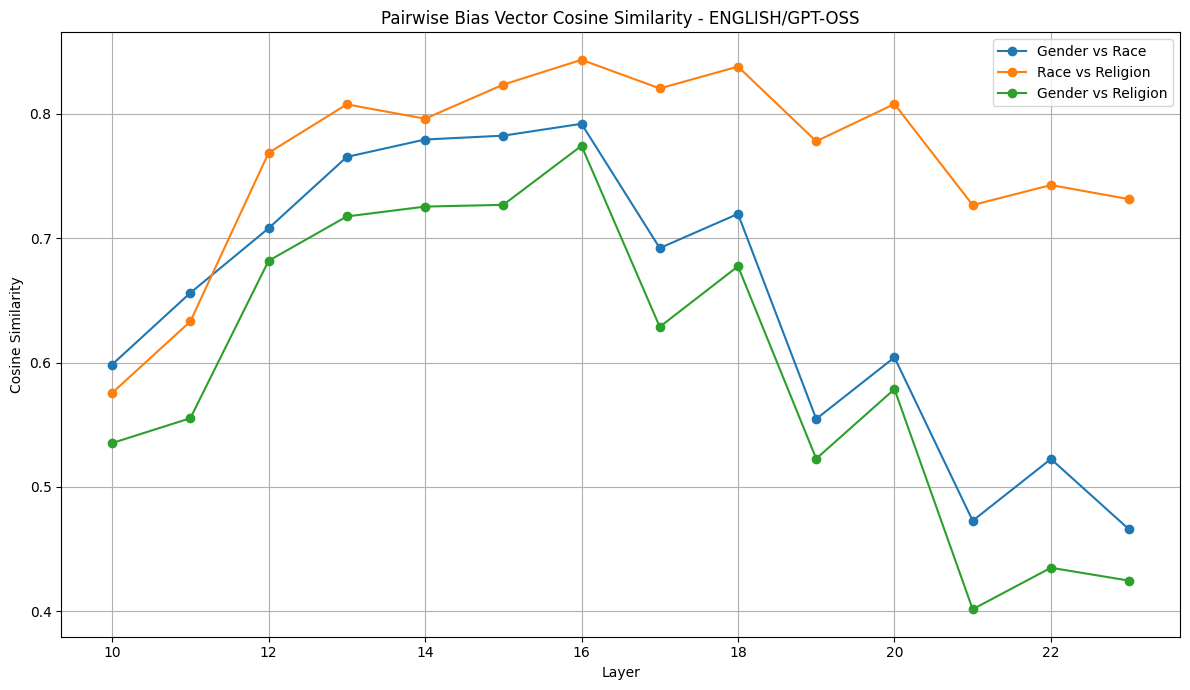

In [2]:
# PAIRWISE BIAS VECTOR COSINE SIMILARITY - ENGLISH / GPT-OSS
# Plots Gender vs Race, Race vs Religion, and Gender vs Religion in one figure

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# GPT-OSS usually has layers 0–23, so layer 10 to 23
layers = list(range(10, 24))

base_dir = "/home/chakrabort/Documents/Gptoss"

vector_pairs = {
    "Gender vs Race": ("gender_rlhf_wrapper", "race_rlhf_wrapper"),
    "Race vs Religion": ("race_rlhf_wrapper", "religion_rlhf_wrapper"),
    "Gender vs Religion": ("gender_rlhf_wrapper", "religion_rlhf_wrapper"),
}

cosine_similarities = {pair_name: [] for pair_name in vector_pairs}

for pair_name, (dir1, dir2) in vector_pairs.items():
    print(f"\nProcessing: {pair_name}")

    for layer in layers:
        vec1_path = f"{base_dir}/{dir1}/vec_layer_{layer}.pt"
        vec2_path = f"{base_dir}/{dir2}/vec_layer_{layer}.pt"

        try:
            vec1 = torch.load(vec1_path, map_location="cpu").float()
            vec2 = torch.load(vec2_path, map_location="cpu").float()

            if vec1.dim() != 1 or vec2.dim() != 1:
                raise ValueError(
                    f"Expected 1D vectors at layer {layer}; "
                    f"got {tuple(vec1.shape)} and {tuple(vec2.shape)}"
                )

            if vec1.numel() != vec2.numel():
                raise ValueError(
                    f"Hidden-size mismatch at layer {layer}: "
                    f"{vec1.numel()} vs {vec2.numel()}"
                )

            sim = F.cosine_similarity(
                vec1.unsqueeze(0),
                vec2.unsqueeze(0),
                dim=1
            )

            cosine_similarities[pair_name].append(sim.item())

        except Exception as e:
            print(f"Layer {layer} skipped for {pair_name}: {e}")
            cosine_similarities[pair_name].append(None)

# Print mean cosine similarities
print("\nMean cosine similarities:")
for pair_name, values in cosine_similarities.items():
    valid_values = [v for v in values if v is not None]

    if len(valid_values) == 0:
        print(f"{pair_name}: N/A")
    else:
        mean_similarity = sum(valid_values) / len(valid_values)
        print(f"{pair_name}: {mean_similarity:.4f}")

# Plot all pairwise similarities in one figure
plt.figure(figsize=(12, 7))

for pair_name, values in cosine_similarities.items():
    plt.plot(
        layers,
        values,
        marker="o",
        label=pair_name
    )

plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.title("Pairwise Bias Vector Cosine Similarity - ENGLISH/GPT-OSS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

GenderVsRace_GPTOSS: [0.5983673334121704, 0.6559827327728271, 0.7079060673713684, 0.765255868434906, 0.7792443633079529, 0.7823458313941956, 0.7918819189071655, 0.6919680237770081, 0.7194695472717285, 0.5546343326568604, 0.6041405200958252, 0.4727943539619446, 0.5224677920341492, 0.4657971262931824]
Mean cosine similarity (gender vs. race): 0.6509


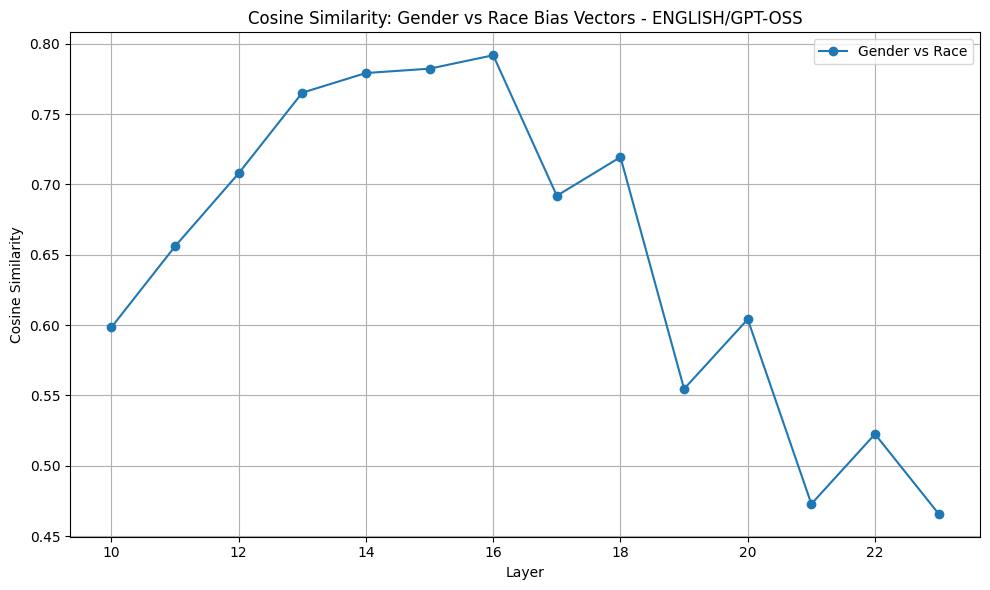

In [1]:
# GENDER VS RACE - ENGLISH / GPT-OSS

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# GPT-OSS usually has layers 0–23, so use 10 to 23
layers = list(range(10, 24))

base_dir = "/home/chakrabort/Documents/Gptoss"

cosine_similarities = []

for layer in layers:
    gender_vec = torch.load(
        f"{base_dir}/gender_rlhf_wrapper/vec_layer_{layer}.pt",
        map_location="cpu"
    ).float()

    race_vec = torch.load(
        f"{base_dir}/race_rlhf_wrapper/vec_layer_{layer}.pt",
        map_location="cpu"
    ).float()

    if gender_vec.dim() != 1 or race_vec.dim() != 1:
        raise ValueError(
            f"Expected 1D vectors at layer {layer}; "
            f"got gender {tuple(gender_vec.shape)} and race {tuple(race_vec.shape)}"
        )

    if gender_vec.numel() != race_vec.numel():
        raise ValueError(
            f"Hidden-size mismatch at layer {layer}: "
            f"gender={gender_vec.numel()}, race={race_vec.numel()}"
        )

    sim = F.cosine_similarity(
        gender_vec.unsqueeze(0),
        race_vec.unsqueeze(0),
        dim=1
    )

    cosine_similarities.append(sim.item())

mean_similarity = sum(cosine_similarities) / len(cosine_similarities)

print("GenderVsRace_GPTOSS:", cosine_similarities)
print(f"Mean cosine similarity (gender vs. race): {mean_similarity:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(
    layers,
    cosine_similarities,
    marker="o",
    label="Gender vs Race"
)

plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.title("Cosine Similarity: Gender vs Race Bias Vectors - ENGLISH/GPT-OSS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

RaceVsReligion_GPTOSS: [0.5755491852760315, 0.6330198049545288, 0.7685436010360718, 0.8074861764907837, 0.7959616184234619, 0.8233752250671387, 0.8433162569999695, 0.8203197717666626, 0.837857723236084, 0.7778222560882568, 0.8077576756477356, 0.7265747785568237, 0.7426273226737976, 0.7312895655632019]
Mean cosine similarity (race vs. religion): 0.7637


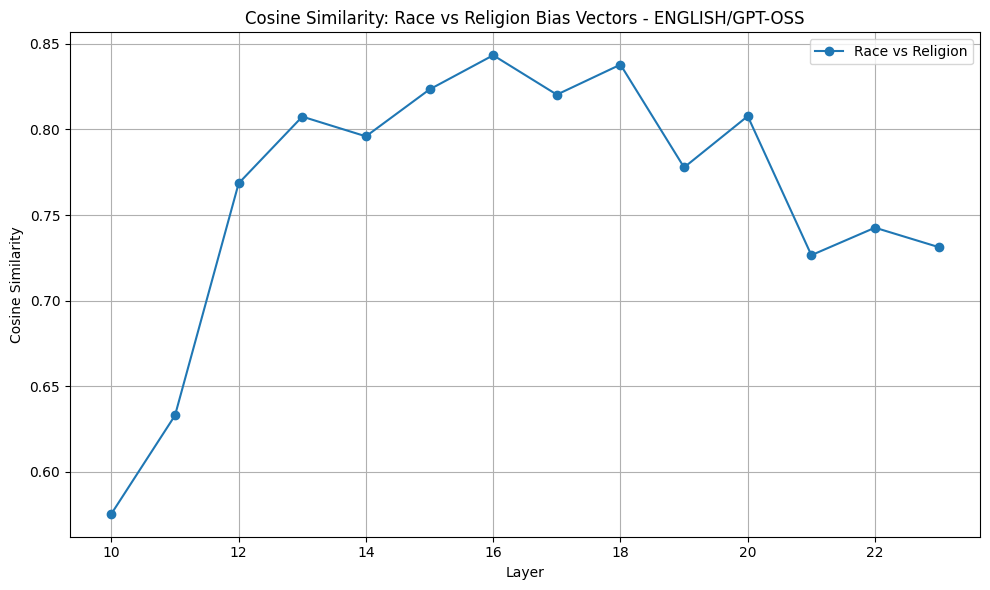

In [2]:
# RACE VS RELIGION - ENGLISH / GPT-OSS

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# GPT-OSS usually has layers 0–23, so use 10 to 23
layers = list(range(10, 24))

base_dir = "/home/chakrabort/Documents/Gptoss"

cosine_similarities = []

for layer in layers:
    race_vec = torch.load(
        f"{base_dir}/race_rlhf_wrapper/vec_layer_{layer}.pt",
        map_location="cpu"
    ).float()

    religion_vec = torch.load(
        f"{base_dir}/religion_rlhf_wrapper/vec_layer_{layer}.pt",
        map_location="cpu"
    ).float()

    if race_vec.dim() != 1 or religion_vec.dim() != 1:
        raise ValueError(
            f"Expected 1D vectors at layer {layer}; "
            f"got race {tuple(race_vec.shape)} and religion {tuple(religion_vec.shape)}"
        )

    if race_vec.numel() != religion_vec.numel():
        raise ValueError(
            f"Hidden-size mismatch at layer {layer}: "
            f"race={race_vec.numel()}, religion={religion_vec.numel()}"
        )

    sim = F.cosine_similarity(
        race_vec.unsqueeze(0),
        religion_vec.unsqueeze(0),
        dim=1
    )

    cosine_similarities.append(sim.item())

mean_similarity = sum(cosine_similarities) / len(cosine_similarities)

print("RaceVsReligion_GPTOSS:", cosine_similarities)
print(f"Mean cosine similarity (race vs. religion): {mean_similarity:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(
    layers,
    cosine_similarities,
    marker="o",
    label="Race vs Religion"
)

plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.title("Cosine Similarity: Race vs Religion Bias Vectors - ENGLISH/GPT-OSS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

GenderVsReligion_GPTOSS: [0.5352494716644287, 0.5552304983139038, 0.6817641258239746, 0.717406690120697, 0.7253268957138062, 0.7267381548881531, 0.7742239832878113, 0.6286476850509644, 0.6773329973220825, 0.5226686000823975, 0.5786077976226807, 0.40166646242141724, 0.4350208044052124, 0.4246579110622406]
Mean cosine similarity (gender vs. religion): 0.5989


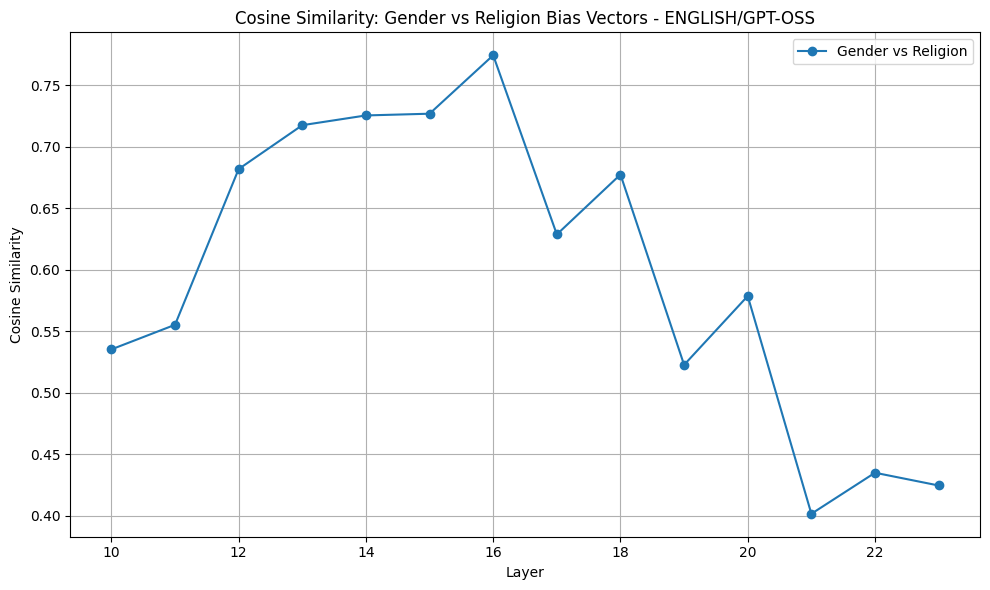

In [3]:
# GENDER VS RELIGION - ENGLISH / GPT-OSS

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# GPT-OSS usually has layers 0–23, so use 10 to 23
layers = list(range(10, 24))

base_dir = "/home/chakrabort/Documents/Gptoss"

cosine_similarities = []

for layer in layers:
    gender_vec = torch.load(
        f"{base_dir}/gender_rlhf_wrapper/vec_layer_{layer}.pt",
        map_location="cpu"
    ).float()

    religion_vec = torch.load(
        f"{base_dir}/religion_rlhf_wrapper/vec_layer_{layer}.pt",
        map_location="cpu"
    ).float()

    if gender_vec.dim() != 1 or religion_vec.dim() != 1:
        raise ValueError(
            f"Expected 1D vectors at layer {layer}; "
            f"got gender {tuple(gender_vec.shape)} and religion {tuple(religion_vec.shape)}"
        )

    if gender_vec.numel() != religion_vec.numel():
        raise ValueError(
            f"Hidden-size mismatch at layer {layer}: "
            f"gender={gender_vec.numel()}, religion={religion_vec.numel()}"
        )

    sim = F.cosine_similarity(
        gender_vec.unsqueeze(0),
        religion_vec.unsqueeze(0),
        dim=1
    )

    cosine_similarities.append(sim.item())

mean_similarity = sum(cosine_similarities) / len(cosine_similarities)

print("GenderVsReligion_GPTOSS:", cosine_similarities)
print(f"Mean cosine similarity (gender vs. religion): {mean_similarity:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(
    layers,
    cosine_similarities,
    marker="o",
    label="Gender vs Religion"
)

plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.title("Cosine Similarity: Gender vs Religion Bias Vectors - ENGLISH/GPT-OSS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### GPTOSS - ITALIAN DATASET

##### BIAS-REFUSAL

GenderVsRefusal_GPTOSS_IT: [0.33061087131500244, 0.2567673325538635, 0.2278653085231781, 0.09113448858261108, -0.08072774857282639, -0.22840534150600433, -0.38759708404541016, -0.22212111949920654, -0.31793123483657837, -0.22428561747074127, -0.2717132270336151, -0.22628319263458252, -0.23061172664165497, -0.27540141344070435]
RaceVsRefusal_GPTOSS_IT: [0.3758459687232971, 0.2728872299194336, 0.16580730676651, 0.09663862735033035, 0.03421365097165108, -0.08277282118797302, -0.17709757387638092, -0.08562982082366943, -0.13282711803913116, -0.10219791531562805, -0.16886602342128754, -0.1597864031791687, -0.17005334794521332, 0.0034307213500142097]
ReligionVsRefusal_GPTOSS_IT: [0.16017279028892517, 0.10092030465602875, 0.10975373536348343, 0.015406418591737747, -0.11191897094249725, -0.21778231859207153, -0.4158656597137451, -0.3338829576969147, -0.3985280692577362, -0.2797929048538208, -0.37788668274879456, -0.2826133370399475, -0.3333071768283844, -0.2507537603378296]

Mean cosine simila

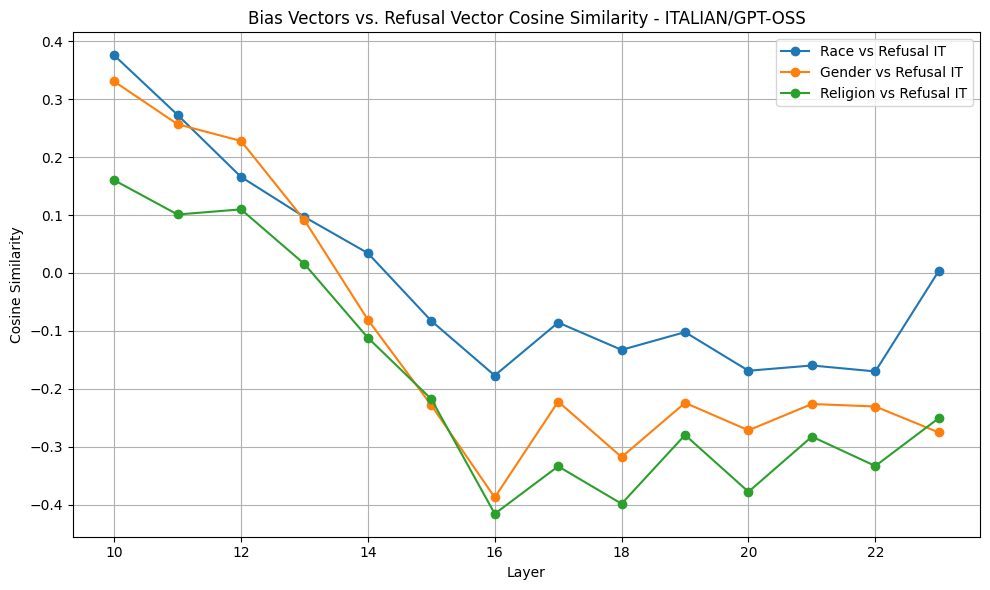

In [5]:
import os
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# GPT-OSS Italian layers
# If your GPT-OSS vectors only go up to layer 23, change this to range(10, 24)
layers = list(range(10, 24))

bias_types = [
    "race_rlhf_wrapper_IT",
    "gender_rlhf_wrapper_IT",
    "religion_rlhf_wrapper_IT",
]

base_dir = "/home/chakrabort/Documents/Gptoss"

cosine_similarities = {bias: [] for bias in bias_types}


def load_vec(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"File does not exist: {path}")

    if os.path.getsize(path) == 0:
        raise ValueError(f"File is empty: {path}")

    try:
        obj = torch.load(
            path,
            map_location="cpu",
            weights_only=False
        )
    except Exception as e:
        print("\nFAILED TO LOAD FILE:")
        print(path)
        print("File size:", os.path.getsize(path), "bytes")
        raise e

    if isinstance(obj, torch.Tensor):
        vec = obj.float()

    elif isinstance(obj, dict):
        possible_keys = ["vec", "vector", "steering_vector", "activation_diff"]

        for key in possible_keys:
            if key in obj and isinstance(obj[key], torch.Tensor):
                vec = obj[key].float()
                break
        else:
            raise ValueError(
                f"Loaded dictionary from {path}, but could not find a tensor key. "
                f"Available keys: {list(obj.keys())}"
            )

    else:
        raise TypeError(
            f"Unsupported object type loaded from {path}: {type(obj)}"
        )

    if vec.dim() != 1:
        raise ValueError(
            f"Expected 1D vector from {path}, got shape {tuple(vec.shape)}"
        )

    return vec


for layer in layers:
    refusal_path = f"{base_dir}/refusal_rlhf_wrapper_IT/vec_layer_{layer}.pt"
    refusal_vec = load_vec(refusal_path)

    for bias in bias_types:
        bias_path = f"{base_dir}/{bias}/vec_layer_{layer}.pt"
        bias_vec = load_vec(bias_path)

        if refusal_vec.numel() != bias_vec.numel():
            raise ValueError(
                f"Hidden-size mismatch at layer {layer} for {bias}: "
                f"refusal={refusal_vec.numel()}, bias={bias_vec.numel()}"
            )

        sim = F.cosine_similarity(
            refusal_vec.unsqueeze(0),
            bias_vec.unsqueeze(0),
            dim=1
        )

        cosine_similarities[bias].append(sim.item())


print("GenderVsRefusal_GPTOSS_IT:", cosine_similarities["gender_rlhf_wrapper_IT"])
print("RaceVsRefusal_GPTOSS_IT:", cosine_similarities["race_rlhf_wrapper_IT"])
print("ReligionVsRefusal_GPTOSS_IT:", cosine_similarities["religion_rlhf_wrapper_IT"])

print("\nMean cosine similarities:")
for bias in bias_types:
    values = cosine_similarities[bias]
    mean_value = sum(values) / len(values)

    clean_name = bias.replace("_rlhf_wrapper_IT", "").capitalize()
    print(f"{clean_name} vs Refusal mean cosine similarity GPT-OSS IT: {mean_value:.4f}")


plt.figure(figsize=(10, 6))

label_map = {
    "gender_rlhf_wrapper_IT": "Gender vs Refusal IT",
    "race_rlhf_wrapper_IT": "Race vs Refusal IT",
    "religion_rlhf_wrapper_IT": "Religion vs Refusal IT",
}

for bias in bias_types:
    plt.plot(
        layers,
        cosine_similarities[bias],
        marker="o",
        label=label_map[bias]
    )

plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.title("Bias Vectors vs. Refusal Vector Cosine Similarity - ITALIAN/GPT-OSS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##### BIAS TRANFERABILITY


Processing: Gender vs Race IT

Processing: Race vs Religion IT

Processing: Gender vs Religion IT

Mean cosine similarities:
Gender vs Race IT: 0.5866
Race vs Religion IT: 0.6391
Gender vs Religion IT: 0.5449


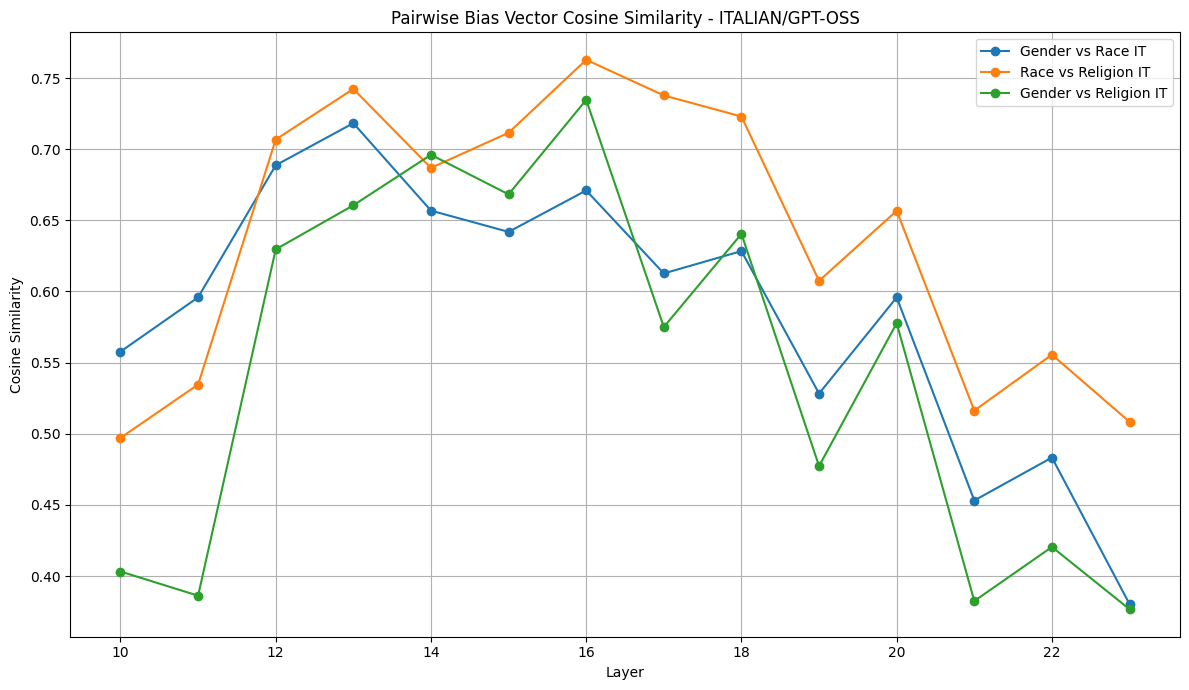

In [6]:
# PAIRWISE BIAS VECTOR COSINE SIMILARITY - ITALIAN / GPT-OSS
# Plots Gender vs Race, Race vs Religion, and Gender vs Religion in one figure

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# If your GPT-OSS vectors only go up to layer 23, use range(10, 24)
layers = list(range(10, 24))

base_dir = "/home/chakrabort/Documents/Gptoss"

vector_pairs = {
    "Gender vs Race IT": ("gender_rlhf_wrapper_IT", "race_rlhf_wrapper_IT"),
    "Race vs Religion IT": ("race_rlhf_wrapper_IT", "religion_rlhf_wrapper_IT"),
    "Gender vs Religion IT": ("gender_rlhf_wrapper_IT", "religion_rlhf_wrapper_IT"),
}

cosine_similarities = {pair_name: [] for pair_name in vector_pairs}

for pair_name, (dir1, dir2) in vector_pairs.items():
    print(f"\nProcessing: {pair_name}")

    for layer in layers:
        vec1_path = f"{base_dir}/{dir1}/vec_layer_{layer}.pt"
        vec2_path = f"{base_dir}/{dir2}/vec_layer_{layer}.pt"

        try:
            vec1 = torch.load(
                vec1_path,
                map_location="cpu",
                weights_only=False
            ).float()

            vec2 = torch.load(
                vec2_path,
                map_location="cpu",
                weights_only=False
            ).float()

            if vec1.dim() != 1 or vec2.dim() != 1:
                raise ValueError(
                    f"Expected 1D vectors at layer {layer}; "
                    f"got {tuple(vec1.shape)} and {tuple(vec2.shape)}"
                )

            if vec1.numel() != vec2.numel():
                raise ValueError(
                    f"Hidden-size mismatch at layer {layer}: "
                    f"{vec1.numel()} vs {vec2.numel()}"
                )

            sim = F.cosine_similarity(
                vec1.unsqueeze(0),
                vec2.unsqueeze(0),
                dim=1
            )

            cosine_similarities[pair_name].append(sim.item())

        except Exception as e:
            print(f"Layer {layer} skipped for {pair_name}: {e}")
            cosine_similarities[pair_name].append(None)

# Print mean cosine similarities
print("\nMean cosine similarities:")
for pair_name, values in cosine_similarities.items():
    valid_values = [v for v in values if v is not None]

    if len(valid_values) == 0:
        print(f"{pair_name}: N/A")
    else:
        mean_similarity = sum(valid_values) / len(valid_values)
        print(f"{pair_name}: {mean_similarity:.4f}")

# Plot all pairwise similarities in one figure
plt.figure(figsize=(12, 7))

for pair_name, values in cosine_similarities.items():
    plt.plot(
        layers,
        values,
        marker="o",
        label=pair_name
    )

plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.title("Pairwise Bias Vector Cosine Similarity - ITALIAN/GPT-OSS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

GenderVsRace_GPTOSS_IT: [0.5577234029769897, 0.5958513021469116, 0.6886913776397705, 0.7182803153991699, 0.6568169593811035, 0.6418718695640564, 0.6709735989570618, 0.6126822233200073, 0.6283856630325317, 0.5282424092292786, 0.595840334892273, 0.4531055688858032, 0.4832875728607178, 0.3803068697452545]
Mean cosine similarity (gender vs. race GPT-OSS IT): 0.5866


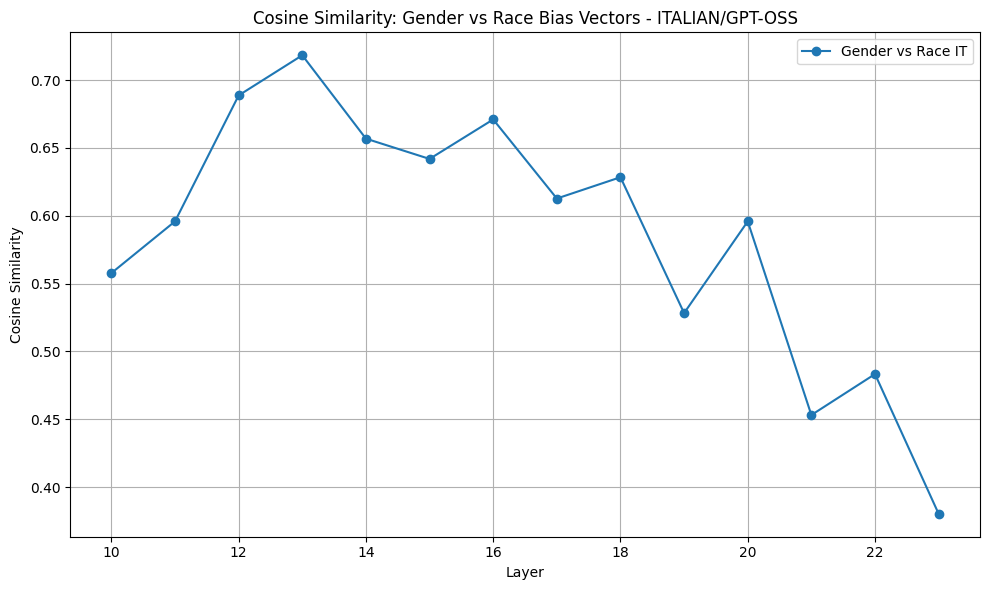

In [8]:
# GENDER VS RACE - ITALIAN / GPT-OSS

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# If your GPT-OSS vectors only go up to layer 23, use range(10, 24)
layers = list(range(10, 24))

cosine_similarities = []

base_dir = "/home/chakrabort/Documents/Gptoss"

for layer in layers:
    gender_vec = torch.load(
        f"{base_dir}/gender_rlhf_wrapper_IT/vec_layer_{layer}.pt",
        map_location="cpu",
        weights_only=False
    ).float()

    race_vec = torch.load(
        f"{base_dir}/race_rlhf_wrapper_IT/vec_layer_{layer}.pt",
        map_location="cpu",
        weights_only=False
    ).float()

    if gender_vec.dim() != 1 or race_vec.dim() != 1:
        raise ValueError(
            f"Expected 1D vectors at layer {layer}; "
            f"got gender {tuple(gender_vec.shape)} and race {tuple(race_vec.shape)}"
        )

    if gender_vec.numel() != race_vec.numel():
        raise ValueError(
            f"Hidden-size mismatch at layer {layer}: "
            f"gender={gender_vec.numel()}, race={race_vec.numel()}"
        )

    sim = F.cosine_similarity(
        gender_vec.unsqueeze(0),
        race_vec.unsqueeze(0),
        dim=1
    )

    cosine_similarities.append(sim.item())

mean_similarity = sum(cosine_similarities) / len(cosine_similarities)

print("GenderVsRace_GPTOSS_IT:", cosine_similarities)
print(f"Mean cosine similarity (gender vs. race GPT-OSS IT): {mean_similarity:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(
    layers,
    cosine_similarities,
    marker="o",
    label="Gender vs Race IT"
)

plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.title("Cosine Similarity: Gender vs Race Bias Vectors - ITALIAN/GPT-OSS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

RaceVsReligion_GPTOSS_IT: [0.4971011281013489, 0.5345798134803772, 0.7067777514457703, 0.742309033870697, 0.6868473291397095, 0.7115034461021423, 0.7627949118614197, 0.7377572655677795, 0.7229461669921875, 0.6074836850166321, 0.6566846370697021, 0.5162798166275024, 0.5555981397628784, 0.5083620548248291]
Mean cosine similarity (race vs. religion GPT-OSS IT): 0.6391


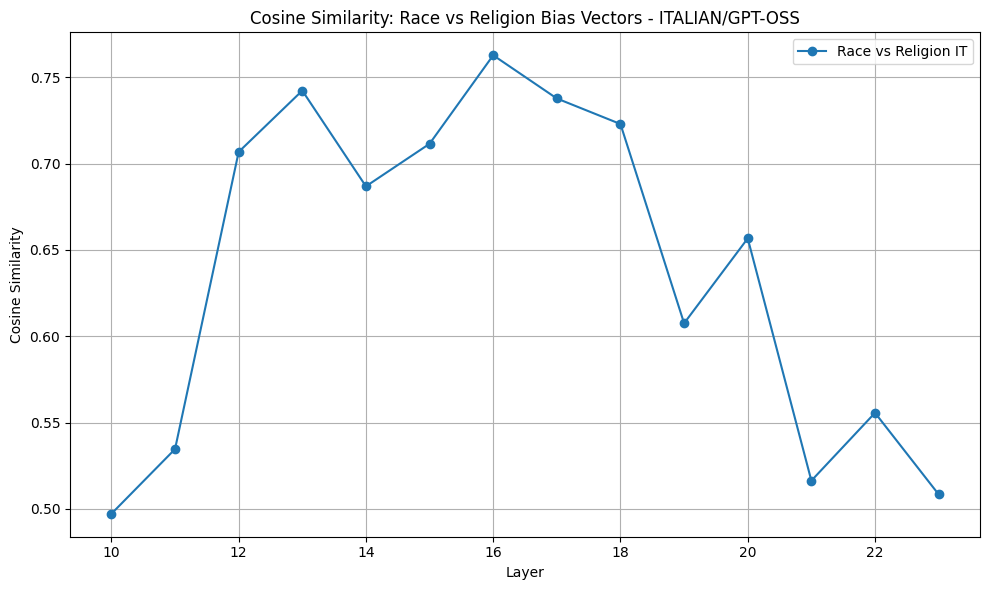

In [10]:
# RACE VS RELIGION - ITALIAN / GPT-OSS

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# If your GPT-OSS vectors only go up to layer 23, use range(10, 24)
layers = list(range(10, 24))

cosine_similarities = []

base_dir = "/home/chakrabort/Documents/Gptoss"

for layer in layers:
    race_vec = torch.load(
        f"{base_dir}/race_rlhf_wrapper_IT/vec_layer_{layer}.pt",
        map_location="cpu",
        weights_only=False
    ).float()

    religion_vec = torch.load(
        f"{base_dir}/religion_rlhf_wrapper_IT/vec_layer_{layer}.pt",
        map_location="cpu",
        weights_only=False
    ).float()

    if race_vec.dim() != 1 or religion_vec.dim() != 1:
        raise ValueError(
            f"Expected 1D vectors at layer {layer}; "
            f"got race {tuple(race_vec.shape)} and religion {tuple(religion_vec.shape)}"
        )

    if race_vec.numel() != religion_vec.numel():
        raise ValueError(
            f"Hidden-size mismatch at layer {layer}: "
            f"race={race_vec.numel()}, religion={religion_vec.numel()}"
        )

    sim = F.cosine_similarity(
        race_vec.unsqueeze(0),
        religion_vec.unsqueeze(0),
        dim=1
    )

    cosine_similarities.append(sim.item())

mean_similarity = sum(cosine_similarities) / len(cosine_similarities)

print("RaceVsReligion_GPTOSS_IT:", cosine_similarities)
print(f"Mean cosine similarity (race vs. religion GPT-OSS IT): {mean_similarity:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(
    layers,
    cosine_similarities,
    marker="o",
    label="Race vs Religion IT"
)

plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.title("Cosine Similarity: Race vs Religion Bias Vectors - ITALIAN/GPT-OSS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 

GenderVsReligion_GPTOSS_IT: [0.4032045304775238, 0.38622355461120605, 0.6295929551124573, 0.660568356513977, 0.696052074432373, 0.6682524681091309, 0.7346378564834595, 0.5749994516372681, 0.640475332736969, 0.4772869944572449, 0.5777249336242676, 0.38246777653694153, 0.4204479455947876, 0.37668538093566895]
Mean cosine similarity (gender vs. religion GPT-OSS IT): 0.5449


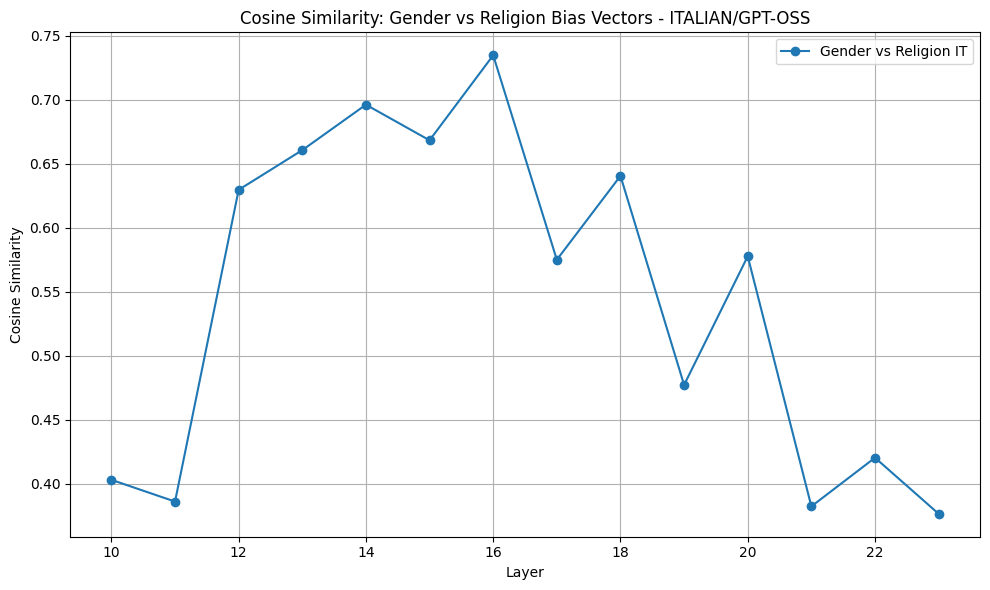

In [11]:
# GENDER VS RELIGION - ITALIAN / GPT-OSS

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# If your GPT-OSS vectors only go up to layer 23, use range(10, 24)
layers = list(range(10, 24))

cosine_similarities = []

base_dir = "/home/chakrabort/Documents/Gptoss"

for layer in layers:
    gender_vec = torch.load(
        f"{base_dir}/gender_rlhf_wrapper_IT/vec_layer_{layer}.pt",
        map_location="cpu",
        weights_only=False
    ).float()

    religion_vec = torch.load(
        f"{base_dir}/religion_rlhf_wrapper_IT/vec_layer_{layer}.pt",
        map_location="cpu",
        weights_only=False
    ).float()

    if gender_vec.dim() != 1 or religion_vec.dim() != 1:
        raise ValueError(
            f"Expected 1D vectors at layer {layer}; "
            f"got gender {tuple(gender_vec.shape)} and religion {tuple(religion_vec.shape)}"
        )

    if gender_vec.numel() != religion_vec.numel():
        raise ValueError(
            f"Hidden-size mismatch at layer {layer}: "
            f"gender={gender_vec.numel()}, religion={religion_vec.numel()}"
        )

    sim = F.cosine_similarity(
        gender_vec.unsqueeze(0),
        religion_vec.unsqueeze(0),
        dim=1
    )

    cosine_similarities.append(sim.item())

mean_similarity = sum(cosine_similarities) / len(cosine_similarities)

print("GenderVsReligion_GPTOSS_IT:", cosine_similarities)
print(f"Mean cosine similarity (gender vs. religion GPT-OSS IT): {mean_similarity:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(
    layers,
    cosine_similarities,
    marker="o",
    label="Gender vs Religion IT"
)

plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.title("Cosine Similarity: Gender vs Religion Bias Vectors - ITALIAN/GPT-OSS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### GPTOSS - ENGLISH/ITALIAN


Processing: Gender EN vs IT

Processing: Race EN vs IT

Processing: Religion EN vs IT

Processing: Refusal EN vs IT

Mean cosine similarities:
Gender EN vs IT: 0.8836
Race EN vs IT: 0.8255
Religion EN vs IT: 0.7205
Refusal EN vs IT: 0.8527


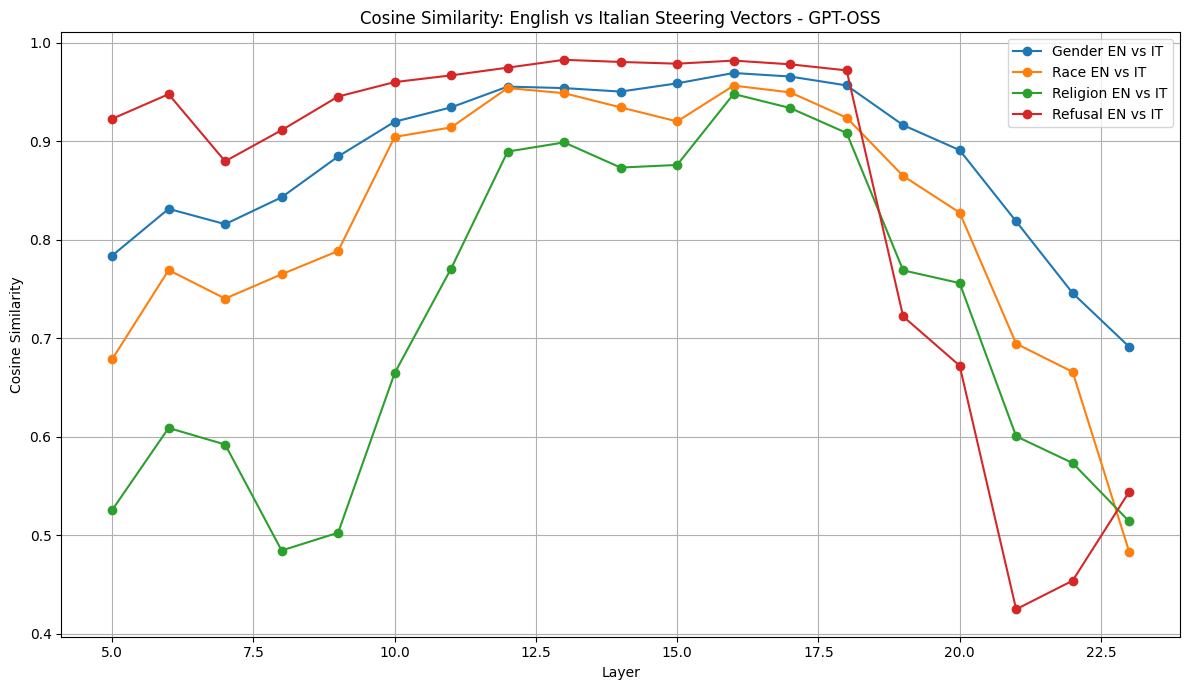

In [12]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import os

# Base directory for GPT-OSS
base_dir = "/home/chakrabort/Documents/Gptoss"

# English vs Italian vector folders for GPT-OSS
vector_pairs = {
    "Gender EN vs IT": ("gender_rlhf_wrapper", "gender_rlhf_wrapper_IT"),
    "Race EN vs IT": ("race_rlhf_wrapper", "race_rlhf_wrapper_IT"),
    "Religion EN vs IT": ("religion_rlhf_wrapper", "religion_rlhf_wrapper_IT"),
    "Refusal EN vs IT": ("refusal_rlhf_wrapper", "refusal_rlhf_wrapper_IT"),
}

# If your GPT-OSS vectors only go up to layer 23, use range(5, 24)
layers = list(range(5, 24))

cosine_similarities = {name: [] for name in vector_pairs}


def load_vec(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"File does not exist: {path}")

    obj = torch.load(
        path,
        map_location="cpu",
        weights_only=False
    )

    if isinstance(obj, torch.Tensor):
        vec = obj.float()
    elif isinstance(obj, dict):
        possible_keys = ["vec", "vector", "steering_vector", "activation_diff"]

        for key in possible_keys:
            if key in obj and isinstance(obj[key], torch.Tensor):
                vec = obj[key].float()
                break
        else:
            raise ValueError(
                f"Loaded dictionary from {path}, but no vector key was found. "
                f"Available keys: {list(obj.keys())}"
            )
    else:
        raise TypeError(f"Unsupported object type loaded from {path}: {type(obj)}")

    if vec.dim() != 1:
        raise ValueError(f"Expected 1D vector from {path}, got shape {tuple(vec.shape)}")

    return vec


for name, (eng_folder, it_folder) in vector_pairs.items():
    print(f"\nProcessing: {name}")

    for layer in layers:
        eng_path = f"{base_dir}/{eng_folder}/vec_layer_{layer}.pt"
        it_path = f"{base_dir}/{it_folder}/vec_layer_{layer}.pt"

        try:
            eng_vec = load_vec(eng_path)
            it_vec = load_vec(it_path)

            if eng_vec.numel() != it_vec.numel():
                raise ValueError(
                    f"Hidden-size mismatch at layer {layer}: "
                    f"{eng_vec.numel()} vs {it_vec.numel()}"
                )

            sim = F.cosine_similarity(
                eng_vec.unsqueeze(0),
                it_vec.unsqueeze(0),
                dim=1
            )

            cosine_similarities[name].append(sim.item())

        except Exception as e:
            print(f"Layer {layer} skipped for {name}: {e}")
            cosine_similarities[name].append(None)


# Print mean cosine similarities
print("\nMean cosine similarities:")
for name, values in cosine_similarities.items():
    valid_values = [v for v in values if v is not None]

    if len(valid_values) == 0:
        print(f"{name}: N/A")
    else:
        mean_similarity = sum(valid_values) / len(valid_values)
        print(f"{name}: {mean_similarity:.4f}")


# Plot all in one figure
plt.figure(figsize=(12, 7))

for name, values in cosine_similarities.items():
    plt.plot(
        layers,
        values,
        marker="o",
        label=name
    )

plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.title("Cosine Similarity: English vs Italian Steering Vectors - GPT-OSS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()